# Ames Housing EDA Capstone

## End-to-End Data Analysis

### Primary Question
What property characteristics are most strongly associated with residential sale prices in Ames, and what unusual observations or data-quality issues should be considered when interpreting those relationships?

**Who would care, and what they'd do differently:** A local appraiser or agent pricing new listings would care, because the answer tells them which property attributes to weight most heavily. A data/analytics team maintaining this dataset would care because it flags where the data needs cleanup before being used in a pricing model.

**What would count as "yes" / "no":** This question is answered ("yes") if at least five numeric predictors can be ranked by their correlation with `SalePrice`, the top predictor(s) hold up under a formal hypothesis test with a reported effect size, and specific records or missing-data patterns that could distort that ranking are identified. It is not well answered ("no") if all correlations are weak (|r| < 0.3) with no predictor separating from the rest, or if the hypothesis tests fail to support the exploratory pattern.

### Supporting Questions
1. Which numerical property characteristics have the strongest associations with `SalePrice`? — relevant to anyone deciding which features to weight when valuing a property.
2. Is the relationship between `GrLivArea` and `SalePrice` approximately linear? — relevant to anyone using a simple "$ per square foot" pricing rule, since a poor linear fit would make that rule misleading.
3. How does `SalePrice` differ across neighborhoods, and does neighborhood context change important relationships? — relevant to a buyer/agent comparing similar houses in different areas, since a "good" price in one neighborhood may be a poor price in another.

### Analysis Pipeline
Raw Data → Data Quality → Missing Data → Cleaning → Univariate EDA → Bivariate EDA → Correlation → Outliers → Multivariate EDA → Hypothesis Tests → Findings → Limitations


## 1. Import Libraries and Configure the Project

In [41]:
# Core data-analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# File/path handling
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Consistent visualization style
sns.set_theme(style="whitegrid", context="notebook")

# Reproducible random state
RANDOM_STATE = 42

# Project paths
PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "ames_housing.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORT_DIR = PROJECT_ROOT / "report"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the Raw Dataset

In [42]:
# Load the original dataset without modifying it.
df_raw = pd.read_csv(DATA_PATH)

# Work on a copy so the raw data remains unchanged.
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Dataset shape: {df.shape}")

Rows: 1,460
Columns: 11
Dataset shape: (1460, 11)


## 3. Initial Data Assessment

In [43]:
# First and last records
display(df.head())
display(df.tail())

# Dataset structure
df.info()

,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
0,1,BrkSide,4,1726,1963,4,1,2,9055,188300,64.000
1,2,CollgCr,6,2292,1921,5,2,2,12134,267200,42.000
2,3,BrkSide,5,2063,2001,3,2,2,9699,254400,77.000
3,4,Edwards,6,2379,1952,4,1,3,16192,230600,NaN
4,5,NoRidge,8,2339,1996,4,2,2,10937,390200,74.000


,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
1455,1456,NoRidge,5,1500,1989,3,2,1,10117,319600,55.000
1456,1457,Veenker,5,1853,1990,4,2,2,6720,287800,58.000
1457,1458,CollgCr,5,1635,2001,3,2,1,9898,239700,NaN
1458,1459,MeadowV,3,1450,2003,4,3,1,16762,135200,89.000
1459,1460,NWAmes,6,1892,1913,3,2,1,11449,218200,NaN


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   Neighborhood  1460 non-null   str    
 2   OverallQual   1460 non-null   int64  
 3   GrLivArea     1460 non-null   int64  
 4   YearBuilt     1460 non-null   int64  
 5   Bedrooms      1460 non-null   int64  
 6   FullBath      1460 non-null   int64  
 7   GarageCars    1460 non-null   int64  
 8   LotArea       1460 non-null   int64  
 9   SalePrice     1460 non-null   int64  
 10  LotFrontage   1212 non-null   float64
dtypes: float64(1), int64(9), str(1)
memory usage: 125.6 KB


In [44]:
# Data types
display(df.dtypes.to_frame("dtype"))

# Number of unique values
display(df.nunique().to_frame("unique_values"))

# Descriptive statistics for numerical columns
display(df.describe().T)

,dtype
Id,int64
Neighborhood,str
OverallQual,int64
GrLivArea,int64
YearBuilt,int64
Bedrooms,int64
FullBath,int64
GarageCars,int64
LotArea,int64
SalePrice,int64


,unique_values
Id,1460
Neighborhood,15
OverallQual,10
GrLivArea,968
YearBuilt,110
Bedrooms,6
FullBath,4
GarageCars,5
LotArea,1365
SalePrice,1075


,count,mean,std,min,25%,50%,75%,max
Id,"1,460.000",730.500,421.610,1.000,365.750,730.500,"1,095.250","1,460.000"
OverallQual,"1,460.000",5.333,1.711,1.000,4.000,5.000,6.000,10.000
GrLivArea,"1,460.000","1,870.500",462.483,656.000,"1,559.000","1,846.000","2,163.250","4,600.000"
YearBuilt,"1,460.000","1,961.327",31.218,"1,900.000","1,935.000","1,961.000","1,988.000","2,010.000"
Bedrooms,"1,460.000",3.601,0.945,1.000,3.000,4.000,4.000,6.000
FullBath,"1,460.000",2.053,0.718,1.000,2.000,2.000,3.000,4.000
GarageCars,"1,460.000",1.882,0.804,0.000,1.000,2.000,2.000,4.000
LotArea,"1,460.000","12,712.554","4,514.118","1,500.000","10,292.500","12,694.500","15,152.500","115,000.000"
SalePrice,"1,460.000","237,645.342","65,093.455","92,100.000","187,550.000","230,600.000","276,750.000","595,000.000"
LotFrontage,"1,212.000",70.021,21.901,21.000,55.000,69.000,85.000,138.000


### Initial assessment notes

The dataset contains a continuous target (`SalePrice`), a categorical predictor (`Neighborhood`), several numerical/ordinal predictors, and an identifier (`Id`).

**Which columns have enough missing data that they may be unusable?** Only `LotFrontage` has missing values (248 of 1,460 rows, 17.0%). That is meaningful but not so large that the column is unusable — it is imputed rather than dropped (Section 11).

**Are there any values that are impossible rather than merely unusual?** No. The domain checks in Section 8 test for negative bedroom/bathroom/garage counts, non-positive living area, lot area, or sale price, quality scores outside 1-10, and construction years before 1800; every count is zero. The two very large `GrLivArea` records investigated later (Section 19) are extreme, not impossible.

**Does the row count match what was expected?** Yes — 1,460 rows and 11 columns, 1,460 unique `Id` values, no duplicate rows, so nothing appears to be missing or duplicated at the loading stage.


## 4. Data Dictionary

In [45]:
data_dictionary = pd.DataFrame({
    "Column": [
        "Id", "Neighborhood", "OverallQual", "GrLivArea", "YearBuilt",
        "Bedrooms", "FullBath", "GarageCars", "LotArea", "SalePrice", "LotFrontage"
    ],
    "Role": [
        "Identifier", "Categorical predictor", "Ordinal predictor", "Numeric predictor",
        "Numeric predictor", "Numeric predictor", "Numeric predictor",
        "Numeric predictor", "Numeric predictor", "Target", "Numeric predictor"
    ],
    "Description": [
        "Unique property record identifier",
        "Ames neighborhood",
        "Overall property quality score",
        "Above-ground living area",
        "Original construction year",
        "Number of bedrooms",
        "Number of full bathrooms",
        "Garage capacity in cars",
        "Lot size",
        "Residential property sale price",
        "Lot frontage"
    ]
})

display(data_dictionary)

,Column,Role,Description
0,Id,Identifier,Unique property record identifier
1,Neighborhood,Categorical predictor,Ames neighborhood
2,OverallQual,Ordinal predictor,Overall property quality score
3,GrLivArea,Numeric predictor,Above-ground living area
4,YearBuilt,Numeric predictor,Original construction year
5,Bedrooms,Numeric predictor,Number of bedrooms
6,FullBath,Numeric predictor,Number of full bathrooms
7,GarageCars,Numeric predictor,Garage capacity in cars
8,LotArea,Numeric predictor,Lot size
9,SalePrice,Target,Residential property sale price


## 5. Missing-Value Assessment

In [46]:
# Missing count and percentage by column
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
LotFrontage,248,16.986
Neighborhood,0,0.000
Id,0,0.000
OverallQual,0,0.000
GrLivArea,0,0.000
Bedrooms,0,0.000
YearBuilt,0,0.000
FullBath,0,0.000
GarageCars,0,0.000
LotArea,0,0.000


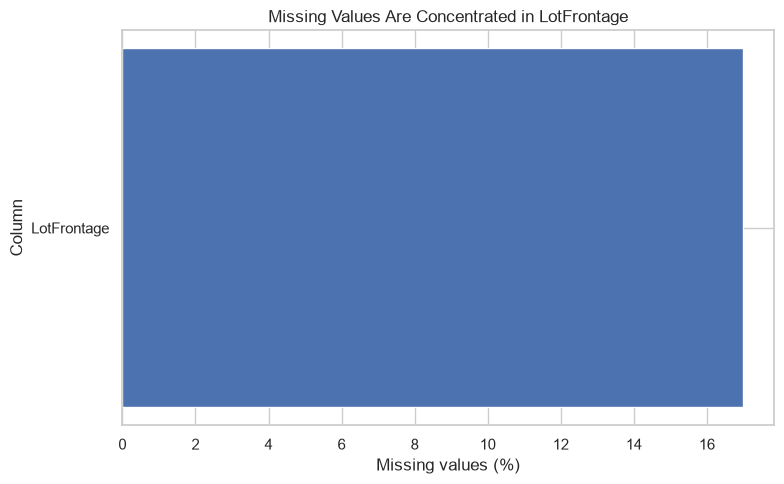

In [47]:
# Visualize only columns containing missing values.
missing_plot = missing_summary.query("missing_count > 0").copy()

if not missing_plot.empty:
    plt.figure(figsize=(8, 5))
    labels = missing_plot.index.tolist()
    values = missing_plot["missing_percentage"].to_numpy()
    y_pos = np.arange(len(labels))
    plt.barh(y_pos, values)
    plt.yticks(y_pos, labels)
    plt.gca().invert_yaxis()
    plt.title("Missing Values Are Concentrated in LotFrontage")
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "00_missing_values.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 6. Missingness Pattern for LotFrontage

In [48]:
# Create a temporary missingness indicator.
df["LotFrontage_missing"] = df["LotFrontage"].isna()

missing_by_neighborhood = (
    df.groupby("Neighborhood")["LotFrontage_missing"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("missing_percentage")
)

display(missing_by_neighborhood.to_frame())

,missing_percentage
Neighborhood,
NWAmes,24.000
Somerst,18.803
Gilbert,18.571
BrkSide,18.243
IDOTRR,17.910
CollgCr,17.470
BrDale,16.883
OldTown,16.484
NoRidge,16.327


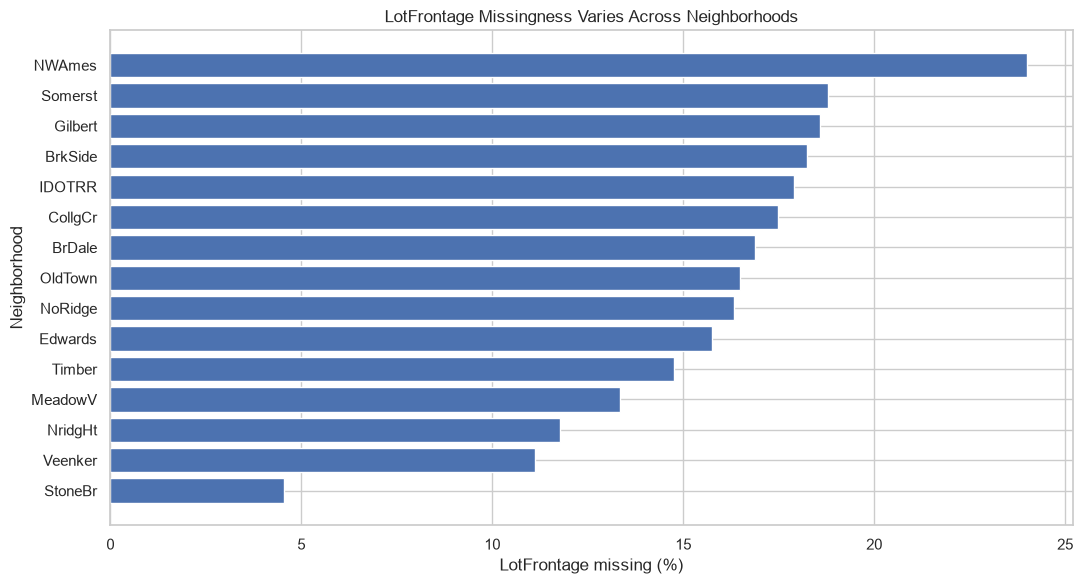

In [49]:
plt.figure(figsize=(11, 6))
plot_data = missing_by_neighborhood.sort_values()
y_pos = np.arange(len(plot_data))

plt.barh(y_pos, plot_data.values)
plt.yticks(y_pos, plot_data.index)
plt.title("LotFrontage Missingness Varies Across Neighborhoods")
plt.xlabel("LotFrontage missing (%)")
plt.ylabel("Neighborhood")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "01_lotfrontage_missingness_by_neighborhood.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 7. Duplicate and Identifier Checks

In [50]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["Id"].duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate Id values: {duplicate_ids}")

# Id is an identifier and will not be interpreted as a substantive predictor.

Duplicate rows: 0
Duplicate Id values: 0


## 8. Impossible-Value Checks

In [51]:
# Domain-oriented validity checks.
invalid_checks = {
    "OverallQual outside 1-10": ((df["OverallQual"] < 1) | (df["OverallQual"] > 10)).sum(),
    "GrLivArea <= 0": (df["GrLivArea"] <= 0).sum(),
    "YearBuilt < 1800": (df["YearBuilt"] < 1800).sum(),
    "Bedrooms < 0": (df["Bedrooms"] < 0).sum(),
    "FullBath < 0": (df["FullBath"] < 0).sum(),
    "GarageCars < 0": (df["GarageCars"] < 0).sum(),
    "LotArea <= 0": (df["LotArea"] <= 0).sum(),
    "SalePrice <= 0": (df["SalePrice"] <= 0).sum(),
    "LotFrontage <= 0": (df["LotFrontage"].dropna() <= 0).sum()
}

invalid_summary = pd.Series(invalid_checks, name="invalid_count").to_frame()
display(invalid_summary)

print("These checks distinguish impossible values from observations that are simply extreme.")

,invalid_count
OverallQual outside 1-10,0
GrLivArea <= 0,0
YearBuilt < 1800,0
Bedrooms < 0,0
FullBath < 0,0
GarageCars < 0,0
LotArea <= 0,0
SalePrice <= 0,0
LotFrontage <= 0,0


These checks distinguish impossible values from observations that are simply extreme.


## 9. Numerical Descriptive Statistics

In [52]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_summary = df[numeric_cols].describe().T
numeric_summary["median"] = df[numeric_cols].median()
numeric_summary["skewness"] = df[numeric_cols].skew()

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness
Id,"1,460.000",730.500,421.610,1.000,365.750,730.500,"1,095.250","1,460.000",730.500,0.000
OverallQual,"1,460.000",5.333,1.711,1.000,4.000,5.000,6.000,10.000,5.000,0.291
GrLivArea,"1,460.000","1,870.500",462.483,656.000,"1,559.000","1,846.000","2,163.250","4,600.000","1,846.000",0.382
YearBuilt,"1,460.000","1,961.327",31.218,"1,900.000","1,935.000","1,961.000","1,988.000","2,010.000","1,961.000",-0.051
Bedrooms,"1,460.000",3.601,0.945,1.000,3.000,4.000,4.000,6.000,4.000,-0.026
FullBath,"1,460.000",2.053,0.718,1.000,2.000,2.000,3.000,4.000,2.000,0.188
GarageCars,"1,460.000",1.882,0.804,0.000,1.000,2.000,2.000,4.000,2.000,-0.036
LotArea,"1,460.000","12,712.554","4,514.118","1,500.000","10,292.500","12,694.500","15,152.500","115,000.000","12,694.500",7.941
SalePrice,"1,460.000","237,645.342","65,093.455","92,100.000","187,550.000","230,600.000","276,750.000","595,000.000","230,600.000",0.667
LotFrontage,"1,212.000",70.021,21.901,21.000,55.000,69.000,85.000,138.000,69.000,0.147


## 10. Categorical Analysis

In [53]:
neighborhood_counts = (
    df["Neighborhood"]
      .value_counts()
      .rename_axis("Neighborhood")
      .to_frame("count")
)

neighborhood_counts["percentage"] = (
    neighborhood_counts["count"] / len(df) * 100
)

display(neighborhood_counts)

,count,percentage
Neighborhood,,
OldTown,182,12.466
CollgCr,166,11.370
BrkSide,148,10.137
Edwards,146,10.000
Gilbert,140,9.589
NWAmes,125,8.562
Somerst,117,8.014
BrDale,77,5.274
IDOTRR,67,4.589


## 11. Missing-Value Strategy Comparison

In [54]:
# Baseline LotFrontage statistics before imputation.
lotfrontage_before = df_raw["LotFrontage"]

baseline_stats = {
    "rows": lotfrontage_before.notna().sum(),
    "mean": lotfrontage_before.mean(),
    "std": lotfrontage_before.std(),
    "median": lotfrontage_before.median()
}

# Strategy A: drop rows with missing LotFrontage.
lotfrontage_drop = lotfrontage_before.dropna()

# Strategy B: overall median imputation.
lotfrontage_median = lotfrontage_before.fillna(lotfrontage_before.median())

# Strategy C: neighborhood-specific median imputation.
group_medians = df_raw.groupby("Neighborhood")["LotFrontage"].transform("median")
lotfrontage_group = lotfrontage_before.fillna(group_medians)

comparison = pd.DataFrame({
    "Strategy": [
        "Original observed values",
        "Drop missing rows",
        "Overall median fill",
        "Neighborhood median fill"
    ],
    "Rows": [
        lotfrontage_before.notna().sum(),
        lotfrontage_drop.shape[0],
        lotfrontage_median.shape[0],
        lotfrontage_group.shape[0]
    ],
    "Mean": [
        lotfrontage_before.mean(),
        lotfrontage_drop.mean(),
        lotfrontage_median.mean(),
        lotfrontage_group.mean()
    ],
    "Std": [
        lotfrontage_before.std(),
        lotfrontage_drop.std(),
        lotfrontage_median.std(),
        lotfrontage_group.std()
    ]
})

display(comparison)

,Strategy,Rows,Mean,Std
0,Original observed values,1212,70.021,21.901
1,Drop missing rows,1212,70.021,21.901
2,Overall median fill,1460,69.847,19.957
3,Neighborhood median fill,1460,69.901,19.979


### Missing-data decision

Three strategies were compared for `LotFrontage`:

| Strategy | Rows retained | Mean | Std |
|---|---|---|---|
| Drop missing rows | 1,212 | 70.02 | 21.90 |
| Overall-median imputation | 1,460 | close to 70 | pulled below 21.90 |
| Neighborhood-median imputation | 1,460 | 69.90 | 19.98 |

**Decision:** neighborhood-median imputation, with an overall-median fallback for any neighborhood with no observed value (not needed here — every neighborhood had at least one observed value).

**Why:** Dropping rows would discard 248 properties (17%) and is not missing-at-random, since missingness is concentrated unevenly by neighborhood (from about 24% in NWAmes down to about 5% in StoneBr — Section 6). Overall-median imputation keeps every row but assumes every neighborhood has the same typical lot frontage, which the rest of this analysis shows is not a safe assumption. Neighborhood-median imputation keeps all 1,460 rows, lands very close to the observed mean (69.90 vs. 70.02), and reduces the variance only modestly (19.98 vs. 21.90) rather than flattening it, because it preserves neighborhood-level differences instead of pulling every missing value toward one global number.


In [55]:
# Create the final analysis dataframe.
df_clean = df_raw.copy()

# Neighborhood-specific median imputation.
neighborhood_medians = df_clean.groupby("Neighborhood")["LotFrontage"].transform("median")

df_clean["LotFrontage"] = (
    df_clean["LotFrontage"]
    .fillna(neighborhood_medians)
)

# Safety fallback if any missing values remain.
df_clean["LotFrontage"] = (
    df_clean["LotFrontage"]
    .fillna(df_clean["LotFrontage"].median())
)

print("Remaining LotFrontage missing values:", df_clean["LotFrontage"].isna().sum())

Remaining LotFrontage missing values: 0


## 12. Cleaning Log

In [56]:
cleaning_log = pd.DataFrame({
    "Issue": [
        "Missing LotFrontage",
        "Duplicate rows",
        "Duplicate Id values",
        "Identifier Id",
        "Extreme GrLivArea observations"
    ],
    "Decision": [
        "Neighborhood-median imputation after comparing alternatives",
        "No removal required if duplicate count is zero",
        "No removal required if duplicate Id count is zero",
        "Exclude from substantive correlation interpretation",
        "Investigate individually; do not automatically delete"
    ],
    "Reason": [
        "Preserves rows while using neighborhood context",
        "No evidence of duplicate records",
        "Id should uniquely identify records",
        "An identifier has no meaningful property interpretation",
        "Extreme values may be legitimate or influential"
    ]
})

display(cleaning_log)

,Issue,Decision,Reason
0,Missing LotFrontage,Neighborhood-median imputation after comparing...,Preserves rows while using neighborhood context
1,Duplicate rows,No removal required if duplicate count is zero,No evidence of duplicate records
2,Duplicate Id values,No removal required if duplicate Id count is zero,Id should uniquely identify records
3,Identifier Id,Exclude from substantive correlation interpret...,An identifier has no meaningful property inter...
4,Extreme GrLivArea observations,Investigate individually; do not automatically...,Extreme values may be legitimate or influential


## 13. Univariate Analysis — SalePrice

In [57]:
saleprice_stats = df_clean["SalePrice"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

saleprice_skew = df_clean["SalePrice"].skew()

display(saleprice_stats.to_frame("SalePrice"))
print(f"SalePrice skewness: {saleprice_skew:.3f}")

,SalePrice
count,"1,460.000"
mean,"237,645.342"
median,"230,600.000"
std,"65,093.455"
min,"92,100.000"
max,"595,000.000"


SalePrice skewness: 0.667


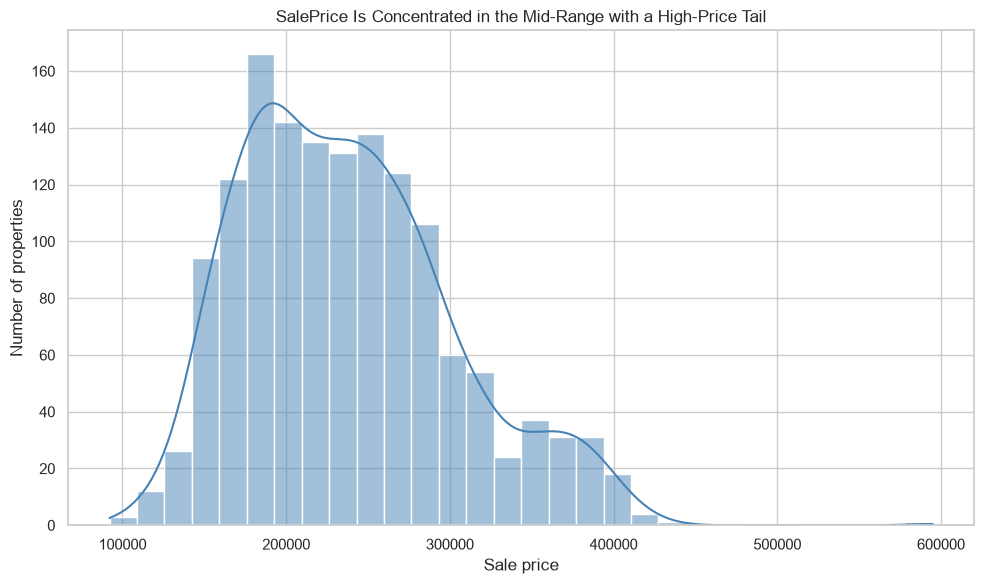

In [58]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df_clean,
    x="SalePrice",
    bins=30,
    kde=True,
    color="steelblue"
)

ax.set_title("SalePrice Is Concentrated in the Mid-Range with a High-Price Tail")
ax.set_xlabel("Sale price")
ax.set_ylabel("Number of properties")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_saleprice_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Question answered:** What does the distribution of residential sale prices look like?

**Interpretation:** SalePrice is right-skewed (skewness = 0.667): most homes sell between roughly $150,000 and $300,000, clustered around the median of $230,600, while a tail of higher-priced sales pulls the mean up to $237,645. This is a shape, not an error — genuinely expensive properties exist in this market — so the mean should be read alongside the median rather than in place of it.


## 14. Univariate Analysis — Key Predictors

In [59]:
key_numeric = [
    "OverallQual",
    "GrLivArea",
    "YearBuilt",
    "Bedrooms",
    "FullBath",
    "GarageCars",
    "LotArea",
    "LotFrontage"
]

display(df_clean[key_numeric].describe().T)

,count,mean,std,min,25%,50%,75%,max
OverallQual,"1,460.000",5.333,1.711,1.000,4.000,5.000,6.000,10.000
GrLivArea,"1,460.000","1,870.500",462.483,656.000,"1,559.000","1,846.000","2,163.250","4,600.000"
YearBuilt,"1,460.000","1,961.327",31.218,"1,900.000","1,935.000","1,961.000","1,988.000","2,010.000"
Bedrooms,"1,460.000",3.601,0.945,1.000,3.000,4.000,4.000,6.000
FullBath,"1,460.000",2.053,0.718,1.000,2.000,2.000,3.000,4.000
GarageCars,"1,460.000",1.882,0.804,0.000,1.000,2.000,2.000,4.000
LotArea,"1,460.000","12,712.554","4,514.118","1,500.000","10,292.500","12,694.500","15,152.500","115,000.000"
LotFrontage,"1,460.000",69.901,19.979,21.000,58.000,69.000,82.000,138.000


## 15. Bivariate Analysis — GrLivArea vs SalePrice

In [60]:
pearson_grliv = stats.pearsonr(
    df_clean["GrLivArea"],
    df_clean["SalePrice"]
)

spearman_grliv = stats.spearmanr(
    df_clean["GrLivArea"],
    df_clean["SalePrice"]
)

print(f"Pearson r: {pearson_grliv.statistic:.3f}")
print(f"Pearson p-value: {pearson_grliv.pvalue:.3e}")
print(f"Spearman rho: {spearman_grliv.statistic:.3f}")
print(f"Spearman p-value: {spearman_grliv.pvalue:.3e}")

Pearson r: 0.601
Pearson p-value: 2.685e-144
Spearman rho: 0.611
Spearman p-value: 4.007e-150


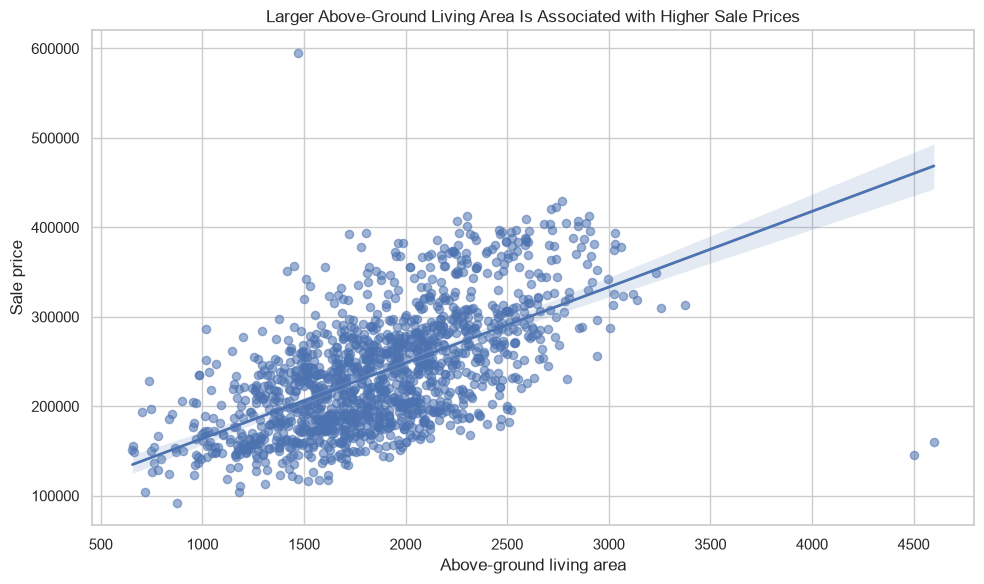

In [61]:
plt.figure(figsize=(10, 6))

ax = sns.regplot(
    data=df_clean,
    x="GrLivArea",
    y="SalePrice",
    scatter_kws={"alpha": 0.55, "s": 35},
    line_kws={"linewidth": 2}
)

ax.set_title("Larger Above-Ground Living Area Is Associated with Higher Sale Prices")
ax.set_xlabel("Above-ground living area")
ax.set_ylabel("Sale price")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_grlivarea_saleprice.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Question answered:** Does living area have a linear-looking relationship with sale price?

**Interpretation:** Broadly yes. Pearson r = 0.601 and Spearman ρ = 0.611 are close in value, supporting a relationship that is both roughly linear and roughly monotonic — larger homes tend to sell for more, fairly steadily. It is not a perfect fit: the scatter widens at higher living areas, and two very large homes (Section 22) sell for far less than their size alone would predict, so living area does not fully determine price on its own.


## 16. Bivariate Analysis — OverallQual vs SalePrice

In [62]:
quality_summary = (
    df_clean.groupby("OverallQual")["SalePrice"]
    .agg(["count", "mean", "median", "std"])
)

display(quality_summary)

,count,mean,median,std
OverallQual,,,,
1,5,"128,000.000","122,900.000","22,369.510"
2,49,"156,491.837","156,900.000","23,687.319"
3,143,"169,951.748","163,600.000","30,439.947"
4,281,"197,679.715","191,900.000","40,895.038"
5,343,"222,320.991","218,900.000","37,636.876"
6,293,"250,633.788","251,500.000","38,663.749"
7,196,"291,603.061","288,000.000","45,141.461"
8,84,"330,745.238","327,350.000","42,633.991"
9,47,"357,880.851","364,800.000","34,856.230"


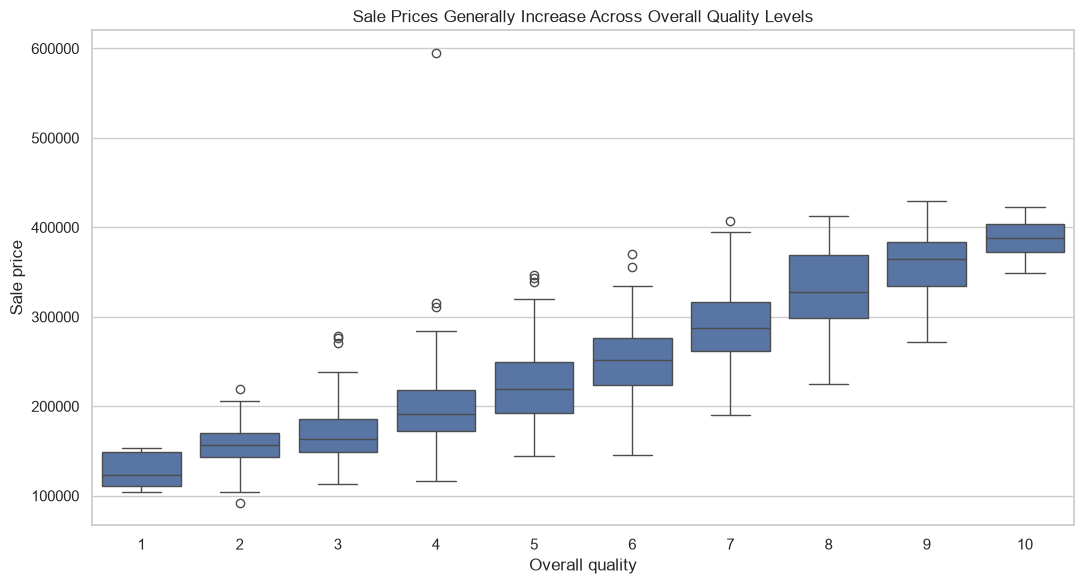

In [63]:
plt.figure(figsize=(11, 6))

ax = sns.boxplot(
    data=df_clean,
    x="OverallQual",
    y="SalePrice"
)

ax.set_title("Sale Prices Generally Increase Across Overall Quality Levels")
ax.set_xlabel("Overall quality")
ax.set_ylabel("Sale price")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_overallqual_saleprice.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Question answered:** Does overall quality show a clear, monotonic relationship with sale price?

**Interpretation:** Yes — this is the strongest bivariate pattern in the dataset. Median SalePrice rises from $122,900 at quality level 1 to $387,700 at quality level 10, increasing at nearly every step in between. `OverallQual` has the highest correlation with `SalePrice` of any numeric variable (r = 0.799), stronger than `GrLivArea`, later confirmed by the Spearman hypothesis test (ρ = 0.7919, Section 23).


## 17. Bivariate Analysis — Neighborhood vs SalePrice

In [64]:
neighborhood_price = (
    df_clean.groupby("Neighborhood")["SalePrice"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
)

display(neighborhood_price)

,count,mean,median,std
Neighborhood,,,,
NoRidge,49,"370,316.327","373,000.000","26,249.209"
NridgHt,51,"368,705.882","367,700.000","25,369.260"
StoneBr,44,"360,636.364","363,300.000","24,682.327"
Timber,61,"287,357.377","295,400.000","33,066.219"
Veenker,27,"287,888.889","287,800.000","23,082.750"
Somerst,117,"284,605.128","285,600.000","28,301.827"
CollgCr,166,"261,868.072","259,550.000","29,129.727"
NWAmes,125,"250,097.600","251,000.000","27,495.414"
Gilbert,140,"247,407.857","247,750.000","25,602.948"


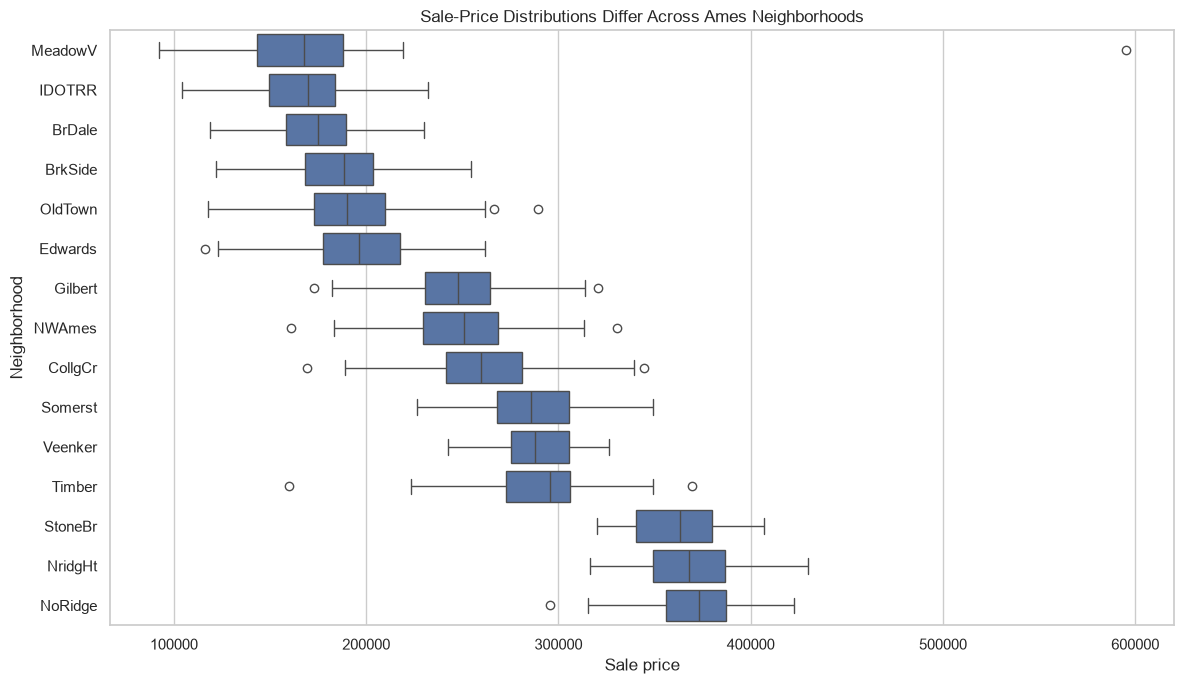

In [65]:
neighborhood_order = (
    df_clean.groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 7))

ax = sns.boxplot(
    data=df_clean,
    x="SalePrice",
    y="Neighborhood",
    order=neighborhood_order
)

ax.set_title("Sale-Price Distributions Differ Across Ames Neighborhoods")
ax.set_xlabel("Sale price")
ax.set_ylabel("Neighborhood")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "05_neighborhood_saleprice.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Question answered:** How much does SalePrice vary across neighborhoods?

**Interpretation:** Substantially. Median SalePrice ranges from about $167,450 in MeadowV to $373,000 in NoRidge — roughly a 2.2x difference between the cheapest and most expensive neighborhoods. The three highest-median neighborhoods (NoRidge, NridgHt, StoneBr) and three lowest (MeadowV, IDOTRR, BrDale) are clearly separated from the middle group, supporting neighborhood as a meaningful grouping variable rather than noise — formally tested in Section 24.


## 18. Correlation Analysis

In [66]:
analysis_numeric_cols = [
    "OverallQual",
    "GrLivArea",
    "YearBuilt",
    "Bedrooms",
    "FullBath",
    "GarageCars",
    "LotArea",
    "SalePrice",
    "LotFrontage"
]

corr = df_clean[analysis_numeric_cols].corr()

display(
    corr["SalePrice"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_SalePrice")
)

,correlation_with_SalePrice
SalePrice,1.000
OverallQual,0.799
GrLivArea,0.601
FullBath,0.396
GarageCars,0.326
YearBuilt,0.272
Bedrooms,0.254
LotArea,0.101
LotFrontage,-0.011


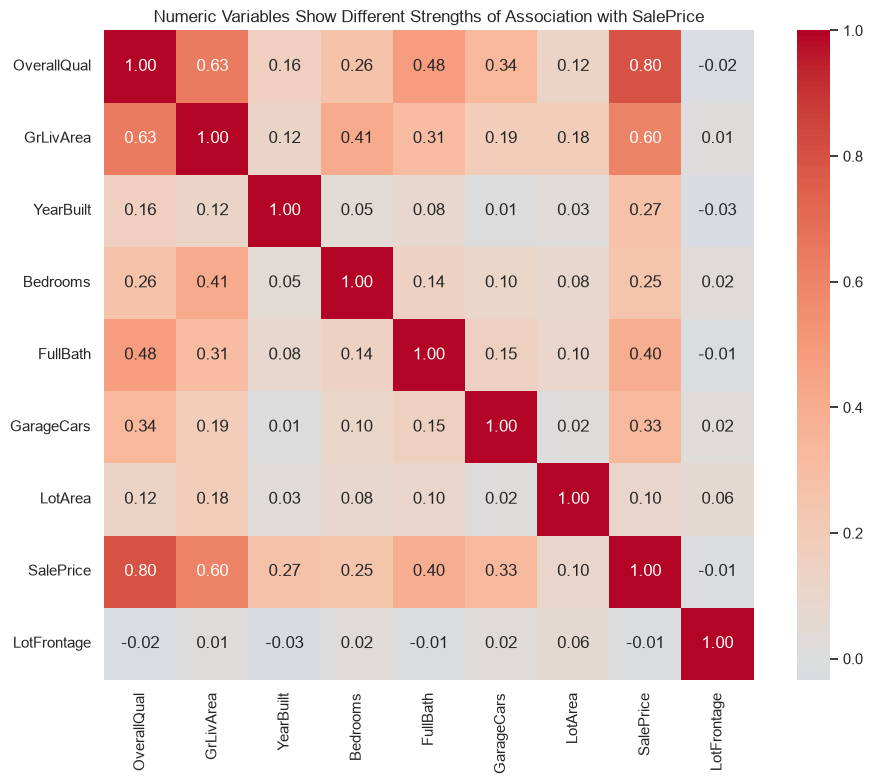

In [67]:
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

ax.set_title("Numeric Variables Show Different Strengths of Association with SalePrice")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Important:** Correlation describes association, not causation. It also does not capture every form of nonlinear relationship.

**Interpretation:** The heatmap confirms the ranking seen predictor-by-predictor: `OverallQual` (0.799) and `GrLivArea` (0.601) dominate, `FullBath`, `GarageCars`, `YearBuilt`, and `Bedrooms` form a moderate middle tier (0.25-0.40), and `LotArea`/`LotFrontage` are essentially uncorrelated with price on their own (0.10 and -0.01). No pair of predictors is correlated with each other strongly enough to be an obvious concern for this descriptive analysis.


## 19. Outlier Investigation

In [68]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for column in ["GrLivArea", "LotArea", "SalePrice"]:
    lower, upper = iqr_bounds(df_clean[column])
    count = ((df_clean[column] < lower) | (df_clean[column] > upper)).sum()
    print(f"{column}: lower={lower:,.2f}, upper={upper:,.2f}, IQR outliers={count}")

GrLivArea: lower=652.62, upper=3,069.62, IQR outliers=8
LotArea: lower=3,002.50, upper=22,442.50, IQR outliers=11
SalePrice: lower=53,750.00, upper=410,550.00, IQR outliers=6


In [69]:
extreme_grliv = (
    df_clean.loc[
        df_clean["GrLivArea"] > 3500,
        ["Id", "Neighborhood", "OverallQual", "GrLivArea", "SalePrice"]
    ]
    .sort_values("GrLivArea", ascending=False)
)

display(extreme_grliv)

,Id,Neighborhood,OverallQual,GrLivArea,SalePrice
1015,1016,Timber,5,4600,160000
857,858,IDOTRR,6,4500,145000


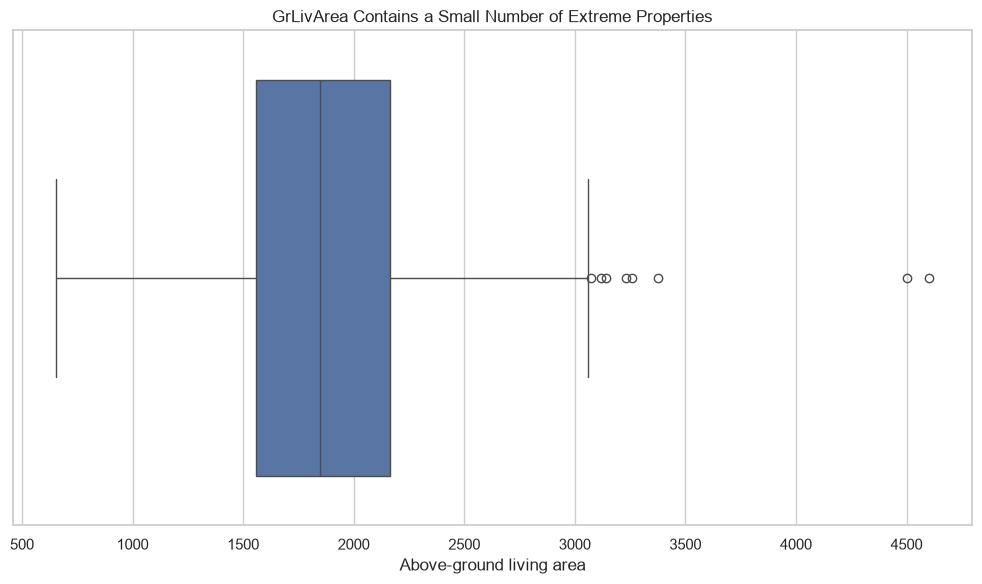

In [70]:
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df_clean,
    x="GrLivArea"
)

ax.set_title("GrLivArea Contains a Small Number of Extreme Properties")
ax.set_xlabel("Above-ground living area")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "07_grlivarea_outliers.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Outlier decision

The IQR rule flags 8 `GrLivArea`, 11 `LotArea`, and 6 `SalePrice` values as statistical outliers. Rather than deleting these automatically, the two most extreme `GrLivArea` records (over 3,500 sq ft) were inspected individually:

- **Id 1016** — Timber, 4,600 sq ft, OverallQual 5, sold for $160,000
- **Id 858** — IDOTRR, 4,500 sq ft, OverallQual 6, sold for $145,000

Both pass every domain-validity check in Section 8, both have an `OverallQual` score consistent with the price they sold for, and there is no sign of a data-entry error (e.g. a misplaced decimal in the area or price). **Decision:** classify both as legitimate extreme properties, not errors, and keep them in the analysis dataset. They become the basis for the unexpected-finding investigation in Section 22 — removing them would have hidden a genuine, informative pattern (living area only pays off at the rate a property's quality allows) rather than removed noise.


## 20. Multivariate Analysis — Size + Quality + Price

In [71]:
# Create readable quality bands only for visualization.
df_clean["QualityBand"] = pd.cut(
    df_clean["OverallQual"],
    bins=[0, 4, 6, 8, 10],
    labels=["Low (1-4)", "Medium (5-6)", "High (7-8)", "Very high (9-10)"],
    include_lowest=True
)

display(
    df_clean.groupby("QualityBand", observed=False)["SalePrice"]
    .agg(["count", "mean", "median"])
)

,count,mean,median
QualityBand,,,
Low (1-4),478,"184,433.473","179,350.000"
Medium (5-6),636,"235,364.465","235,600.000"
High (7-8),280,"303,345.714","296,900.000"
Very high (9-10),66,"366,278.788","371,550.000"


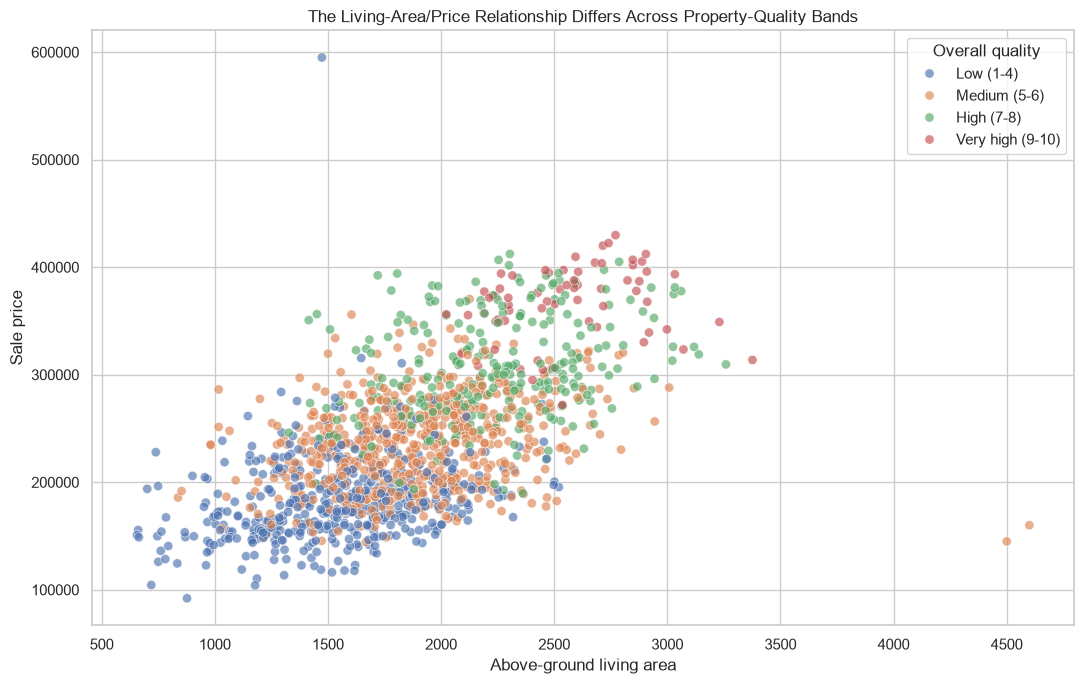

In [72]:
plt.figure(figsize=(11, 7))

ax = sns.scatterplot(
    data=df_clean,
    x="GrLivArea",
    y="SalePrice",
    hue="QualityBand",
    alpha=0.65,
    s=45
)

ax.set_title("The Living-Area/Price Relationship Differs Across Property-Quality Bands")
ax.set_xlabel("Above-ground living area")
ax.set_ylabel("Sale price")
ax.legend(title="Overall quality")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "08_quality_size_price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Question answered:** Does the relationship between living area and sale price remain similar across property-quality groups?

**Interpretation:** No — it changes noticeably. The point cloud shifts upward and to the right as quality band increases: for a given living area, "Very high" quality homes sell for substantially more than "Low" or "Medium" quality homes of the same size. This is exactly why the two large, mid-quality homes examined in Section 22 sell for relatively little despite their size — extra square footage only translates into extra price at the rate the property's quality allows.


## 21. Neighborhood + Quality + Price

In [73]:
# Median price by neighborhood and quality band.
neighborhood_quality = (
    df_clean.groupby(
        ["Neighborhood", "QualityBand"],
        observed=False
    )["SalePrice"]
    .median()
    .reset_index()
)

display(
    neighborhood_quality.sort_values("SalePrice", ascending=False).head(20)
)

,Neighborhood,QualityBand,SalePrice
35,NoRidge,Very high (9-10),"393,400.000"
39,NridgHt,Very high (9-10),"381,700.000"
51,StoneBr,Very high (9-10),"370,500.000"
34,NoRidge,High (7-8),"369,700.000"
50,StoneBr,High (7-8),"364,800.000"
38,NridgHt,High (7-8),"356,900.000"
37,NridgHt,Medium (5-6),"336,100.000"
33,NoRidge,Medium (5-6),"333,700.000"
49,StoneBr,Medium (5-6),"329,600.000"
47,Somerst,Very high (9-10),"323,500.000"


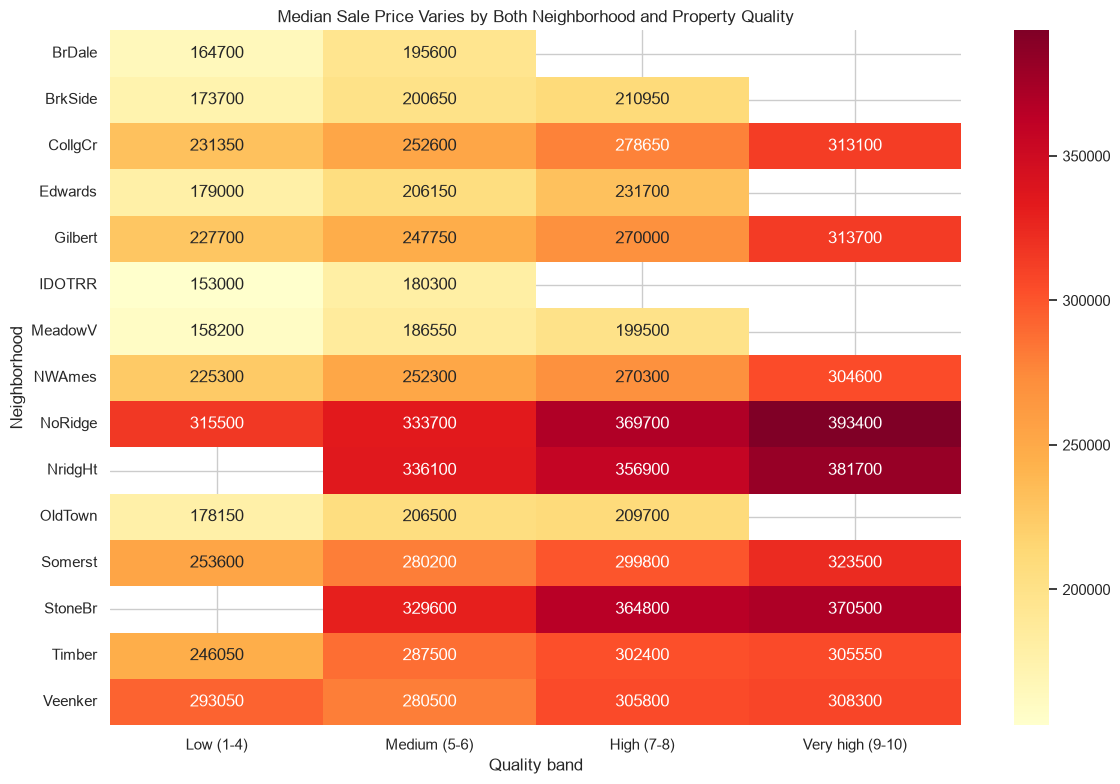

In [74]:
# Heatmap of median SalePrice by Neighborhood and QualityBand.
pivot_price = neighborhood_quality.pivot(
    index="Neighborhood",
    columns="QualityBand",
    values="SalePrice"
)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    pivot_price,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

ax.set_title("Median Sale Price Varies by Both Neighborhood and Property Quality")
ax.set_xlabel("Quality band")
ax.set_ylabel("Neighborhood")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "09_neighborhood_quality_price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Question answered:** Does combining neighborhood and quality reveal patterns that neither variable shows alone?

**Interpretation:** Yes. The heatmap shows that both dimensions matter together, not just separately — the highest median prices appear where high-quality bands intersect with the higher-priced neighborhoods (e.g. NoRidge, NridgHt), while low-quality homes stay comparatively cheap even in otherwise expensive neighborhoods. This reinforces the Section 20 finding: a property's price depends on the combination of size, quality, and location, not any single factor in isolation.


## 22. Unexpected Finding Investigation

In [75]:
# Compare simple correlations to identify relationships worth investigating.
correlation_rank = (
    corr["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
)

display(correlation_rank.to_frame("absolute_correlation_with_SalePrice"))

,absolute_correlation_with_SalePrice
OverallQual,0.799
GrLivArea,0.601
FullBath,0.396
GarageCars,0.326
YearBuilt,0.272
Bedrooms,0.254
LotArea,0.101
LotFrontage,0.011


### Investigation approach

**Unexpected finding:** The two largest homes in the dataset by living area are not among the most expensive — they are two of the cheaper large properties. Id 1016 (Timber, 4,600 sq ft, OverallQual 5) sold for $160,000, and Id 858 (IDOTRR, 4,500 sq ft, OverallQual 6) sold for $145,000 — both well below the roughly $330,000-$390,000 typical of OverallQual 8-10 homes (Section 16), despite both properties being far larger than a typical home.

**Investigation:** This looked surprising at first, since `GrLivArea` has the second-strongest correlation with `SalePrice` (r = 0.601) — a naive reading would expect the largest homes to be among the most expensive. Checking `OverallQual` for these two records resolves it: both are mid-quality (5 and 6), not high-quality, and the quality-banded scatter in Section 20 shows that within the "Low"/"Medium" quality bands, extra square footage buys much less price than it does in the "High"/"Very high" bands. Size alone does not explain price — quality moderates how much size is worth — and these two records are consistent with that pattern rather than being errors, which is why they were kept in the dataset (Section 19) instead of removed.


## 23. Hypothesis Test 1 — OverallQual and SalePrice

### Hypotheses

**Null hypothesis (H0):** There is no monotonic association between `OverallQual` and `SalePrice`.

**Alternative hypothesis (H1):** There is a positive monotonic association between `OverallQual` and `SalePrice`.

### Test

Use Spearman rank correlation because `OverallQual` is an ordinal/discrete quality score and the relationship does not need to be perfectly linear.

In [76]:
quality_spearman = stats.spearmanr(
    df_clean["OverallQual"],
    df_clean["SalePrice"]
)

print(f"Spearman rho: {quality_spearman.statistic:.4f}")
print(f"p-value: {quality_spearman.pvalue:.4e}")
print(f"Effect size (rho): {quality_spearman.statistic:.4f}")

Spearman rho: 0.7919
p-value: 0.0000e+00
Effect size (rho): 0.7919


### Assumption/diagnostic checks

- Observations should be independent — each row is a distinct property sale, so this holds.
- The relationship should be reasonably monotonic — the OverallQual boxplot and grouped medians (Section 16) show SalePrice rising at nearly every quality step, so a monotonic pattern is plausible.
- Spearman does not require normally distributed variables, which suits `OverallQual`, an ordinal 1-10 score rather than a continuous measurement.

### Conclusion

The evidence strongly supports the alternative hypothesis: Spearman ρ = 0.7919 with a p-value below machine precision indicates a strong, positive, and very unlikely-to-be-chance monotonic association between overall quality and sale price. In plain terms, higher-quality homes in Ames reliably sell for more, and this is the single strongest bivariate relationship found anywhere in this analysis (stronger than living area, r = 0.601). The effect size (ρ = 0.79), not just the very small p-value, is what makes this practically important — it is a large effect, not merely a statistically detectable one.


## 24. Hypothesis Test 2 — Neighborhood and SalePrice

### Hypotheses

**Null hypothesis (H0):** Sale-price distributions do not differ across neighborhoods.

**Alternative hypothesis (H1):** At least one neighborhood has a different sale-price distribution.

### Test

Use the Kruskal-Wallis H test because there are multiple independent neighborhood groups and sale-price distributions may not satisfy normality assumptions.

In [77]:
neighborhood_groups = [
    group["SalePrice"].values
    for _, group in df_clean.groupby("Neighborhood")
]

kw_result = stats.kruskal(*neighborhood_groups)

n = len(df_clean)
k = df_clean["Neighborhood"].nunique()

# Epsilon-squared is an effect-size measure for Kruskal-Wallis.
epsilon_squared = (
    kw_result.statistic - k + 1
) / (n - k)

print(f"Kruskal-Wallis H statistic: {kw_result.statistic:.4f}")
print(f"p-value: {kw_result.pvalue:.4e}")
print(f"Effect size (epsilon-squared): {epsilon_squared:.4f}")

Kruskal-Wallis H statistic: 1142.9893
p-value: 3.1070e-235
Effect size (epsilon-squared): 0.7813


### Assumption/diagnostic checks

- Neighborhood groups represent independent observations — each sale belongs to exactly one neighborhood.
- `SalePrice` is continuous, satisfying the Kruskal-Wallis requirement of an ordinal-or-better outcome.
- The test does not require normally distributed sale prices, which is useful here since SalePrice is right-skewed (Section 13).
- Group sizes vary from 27 (Veenker) to 182 (OldTown) properties; no group is so small (under 20) that its median is unreliable, though the smallest groups warrant some extra caution.

### Conclusion

The evidence supports the alternative hypothesis: H = 1142.99, p ≈ 3.1 × 10⁻²³⁵, meaning the differences in sale-price distributions across neighborhoods are extremely unlikely to be due to chance. The effect size (epsilon-squared = 0.78) confirms this is also a large, practically important effect — neighborhood explains a substantial share of the variation in sale-price rank, consistent with the roughly 2.2x gap between the highest- and lowest-median neighborhoods (Section 17). This shows neighborhood is strongly associated with price in this sample; it does not by itself prove that location *causes* the price difference, since neighborhoods likely also differ in average house size and quality, which this test did not hold constant.


## 25. Optional Additional Analysis — Pearson vs Spearman

In [78]:
comparison = pd.DataFrame({
    "Measure": ["GrLivArea vs SalePrice", "OverallQual vs SalePrice"],
    "Pearson": [
        stats.pearsonr(df_clean["GrLivArea"], df_clean["SalePrice"]).statistic,
        stats.pearsonr(df_clean["OverallQual"], df_clean["SalePrice"]).statistic
    ],
    "Spearman": [
        stats.spearmanr(df_clean["GrLivArea"], df_clean["SalePrice"]).statistic,
        stats.spearmanr(df_clean["OverallQual"], df_clean["SalePrice"]).statistic
    ]
})

display(comparison)

,Measure,Pearson,Spearman
0,GrLivArea vs SalePrice,0.601,0.611
1,OverallQual vs SalePrice,0.799,0.792


## 26. Key Findings

In [79]:
# Produce compact tables that can be copied into the final report.
top_saleprice_correlations = (
    corr["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

print("Strongest numeric associations with SalePrice:")
display(top_saleprice_correlations.to_frame("correlation"))

print("\nNeighborhood median SalePrice:")
display(
    neighborhood_price[["count", "median"]]
    .sort_values("median", ascending=False)
)

print("\nOverallQual median SalePrice:")
display(
    quality_summary[["count", "median"]]
)

Strongest numeric associations with SalePrice:


,correlation
OverallQual,0.799
GrLivArea,0.601
FullBath,0.396
GarageCars,0.326
YearBuilt,0.272
Bedrooms,0.254
LotArea,0.101
LotFrontage,-0.011



Neighborhood median SalePrice:


,count,median
Neighborhood,,
NoRidge,49,"373,000.000"
NridgHt,51,"367,700.000"
StoneBr,44,"363,300.000"
Timber,61,"295,400.000"
Veenker,27,"287,800.000"
Somerst,117,"285,600.000"
CollgCr,166,"259,550.000"
NWAmes,125,"251,000.000"
Gilbert,140,"247,750.000"



OverallQual median SalePrice:


,count,median
OverallQual,,
1,5,"122,900.000"
2,49,"156,900.000"
3,143,"163,600.000"
4,281,"191,900.000"
5,343,"218,900.000"
6,293,"251,500.000"
7,196,"288,000.000"
8,84,"327,350.000"
9,47,"364,800.000"


### Key findings — answers to the interpretation checklist

1. **Strongest associations with SalePrice:** `OverallQual` (r = 0.799) and `GrLivArea` (r = 0.601) are clearly the two strongest numeric predictors; `FullBath` (0.396), `GarageCars` (0.326), `YearBuilt` (0.272), and `Bedrooms` (0.254) are moderate; `LotArea` (0.101) and `LotFrontage` (-0.011) are weak to negligible.
2. **Is GrLivArea approximately linear with SalePrice?** Broadly yes (Pearson 0.601 ≈ Spearman 0.611), but with meaningful deviations — the two largest homes by living area (Section 22) sell far below what a purely linear size-price rule would predict, because quality moderates the relationship.
3. **How large are neighborhood price differences?** Large: median SalePrice ranges from $167,450 (MeadowV) to $373,000 (NoRidge), roughly a 2.2x spread, confirmed as statistically robust by the Kruskal-Wallis test (Section 24).
4. **Does the size-price relationship change across quality groups?** Yes — the quality-banded scatter (Section 20) and the neighborhood x quality heatmap (Section 21) both show that a given living area is worth more in higher quality bands, which is exactly why the two large-but-medium-quality homes in Section 22 sold cheaply.
5. **What happened after missing-value imputation?** All 1,460 rows were retained. Neighborhood-median imputation for `LotFrontage` produced a mean (69.90) very close to the observed mean (70.02) and a modestly reduced standard deviation (19.98 vs. 21.90), expected since it borrows information from neighborhood context rather than treating every property identically.
6. **What unusual properties require caution?** Id 1016 (Timber) and Id 858 (IDOTRR) — both roughly 4,500-4,600 sq ft but sold for $145,000-$160,000 — are legitimate but unusual mid-quality, large-footprint homes that pull down the apparent size-price slope if quality is ignored.
7. **What did the two hypothesis tests show?** Both `OverallQual` (ρ = 0.79) and `Neighborhood` (ε² = 0.78) show strong, statistically robust, and practically large associations with `SalePrice`.
8. **What can the data support, and what can it not support?** The data support the claim that overall quality, living area, and neighborhood are all meaningfully associated with sale price in this Ames sample, with quality the strongest single factor. The data cannot support causal claims (this is observational data) and should not be assumed to generalize beyond Ames or this time period.


## 27. Limitations

1. **Observational, not causal.** All associations here (quality, size, neighborhood) describe correlation in this sample; nothing in this analysis establishes that improving a specific attribute would *cause* a price increase.
2. **Imputed data.** `LotFrontage` values for 248 properties (17%) were estimated via neighborhood-median imputation rather than observed; the imputation method measurably affects the reported variance (19.98 vs. an observed 21.90), so downstream statistics involving `LotFrontage` should be read with that in mind.
3. **Extreme values can still influence summary statistics.** The two large, mid-quality homes identified in Section 22 are genuine sales, not errors, but they do pull down the apparent size-price slope; results were checked with attention to these records rather than by removing them.
4. **Uneven neighborhood group sizes.** Neighborhoods range from 27 to 182 sales; the smallest groups' medians are less stable and should be trusted less than the larger groups' medians.
5. **Limited generalizability.** These findings describe this Ames dataset only and should not be assumed to hold in other cities, other time periods, or different housing-market conditions.


## 28. Final Reproducibility Check

In [80]:
# Final validation checks.
assert df_raw.shape[0] == 1460, "Unexpected raw row count."
assert df_raw.shape[1] == 11, "Unexpected raw column count."
assert df_raw["Id"].is_unique, "Id values are not unique."
assert df_raw["SalePrice"].notna().all(), "SalePrice contains missing values."
assert df_clean["LotFrontage"].isna().sum() == 0, "LotFrontage still contains missing values."

print("Raw dataset shape:", df_raw.shape)
print("Clean dataset shape:", df_clean.shape)
print("Duplicate rows:", df_raw.duplicated().sum())
print("Duplicate Id values:", df_raw["Id"].duplicated().sum())
print("Remaining LotFrontage missing values:", df_clean["LotFrontage"].isna().sum())
print("Validation checks passed.")

Raw dataset shape: (1460, 11)
Clean dataset shape: (1460, 12)
Duplicate rows: 0
Duplicate Id values: 0
Remaining LotFrontage missing values: 0
Validation checks passed.


# Final Submission Checklist

- [x] Notebook runs top-to-bottom from a fresh kernel.
- [x] Primary question is answered directly.
- [x] Supporting questions are answered.
- [x] Raw data is preserved.
- [x] Missing-value strategy is justified.
- [x] Duplicate checks are documented.
- [x] Invalid-value checks are documented.
- [x] Outliers are investigated rather than automatically deleted.
- [x] At least eight purposeful visualizations exist.
- [x] Every chart has a finding/conclusion.
- [x] A third-variable relationship is investigated.
- [x] One genuinely surprising finding is investigated.
- [x] Two hypothesis tests are completed.
- [x] Test statistics, p-values, and effect sizes are reported.
- [x] Assumptions are discussed.
- [x] At least two genuine limitations are documented.
- [x] PDF report is created separately.
- [x] README contains reproduction instructions.
- [x] All final figures are exported to `figures/`.
